<a href="https://colab.research.google.com/github/JosephBless/Deep-Learning-Colab/blob/main/Chap_2%EF%BC%9A%E7%8D%B2%E5%8F%96%E9%87%91%E8%9E%8D%E6%95%B8%E6%93%9A.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

在量化投資中，金融數據是基礎。獲取、清洗並處理這些數據是構建量化策略的第一步。今天將介紹如何使用 Python 獲取金融數據，並進行基本的數據檢視和處理。

In [ ]:
# Colab 進行matplotlib繪圖時顯示繁體中文
# 下載台北思源黑體並命名taipei_sans_tc_beta.ttf，移至指定路徑
!wget -O TaipeiSansTCBeta-Regular.ttf https://drive.google.com/uc?id=1eGAsTN1HBpJAkeVM57_C7ccp7hbgSz3_&export=download

import matplotlib

# 改style要在改font之前
# plt.style.use('seaborn')

matplotlib.font_manager.fontManager.addfont('TaipeiSansTCBeta-Regular.ttf')
matplotlib.rc('font', family='Taipei Sans TC Beta')

--2024-09-17 13:44:49--  https://drive.google.com/uc?id=1eGAsTN1HBpJAkeVM57_C7ccp7hbgSz3_
Resolving drive.google.com (drive.google.com)... 74.125.20.138, 74.125.20.113, 74.125.20.100, ...
Connecting to drive.google.com (drive.google.com)|74.125.20.138|:443... connected.
HTTP request sent, awaiting response... 303 See Other
Location: https://drive.usercontent.google.com/download?id=1eGAsTN1HBpJAkeVM57_C7ccp7hbgSz3_ [following]
--2024-09-17 13:44:50--  https://drive.usercontent.google.com/download?id=1eGAsTN1HBpJAkeVM57_C7ccp7hbgSz3_
Resolving drive.usercontent.google.com (drive.usercontent.google.com)... 173.194.202.132, 2607:f8b0:400e:c00::84
Connecting to drive.usercontent.google.com (drive.usercontent.google.com)|173.194.202.132|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 20659344 (20M) [application/octet-stream]
Saving to: ‘TaipeiSansTCBeta-Regular.ttf’

TaipeiSansTCBeta-Re 100%[===================>]  19.70M  --.-KB/s    in 0.1s    

2024-09-17 13:44:56

### 1. 使用 `yfinance` 下載金融數據

`yfinance` 是一個常用的 Python 庫，用於從 Yahoo Finance 下載歷史金融數據，包括股票價格、指數、匯率等。

#### 安裝 `yfinance`
首先，你需要安裝 `yfinance` 庫：

In [ ]:
!pip install yfinance

#### 下載股票數據
以下是一個下載單隻股票（例如蘋果公司，代碼 AAPL）的示例：

In [ ]:
import yfinance as yf

# 下載蘋果公司的歷史數據
stock_data = yf.download('AAPL', start='2020-01-01', end='2024-01-01')

# 檢視前五行數據
print("\n")
print(stock_data.head())


[*********************100%***********************]  1 of 1 completed



                 Open       High        Low      Close  Adj Close     Volume
Date                                                                        
2020-01-02  74.059998  75.150002  73.797501  75.087502  72.876106  135480400
2020-01-03  74.287498  75.144997  74.125000  74.357498  72.167595  146322800
2020-01-06  73.447502  74.989998  73.187500  74.949997  72.742645  118387200
2020-01-07  74.959999  75.224998  74.370003  74.597504  72.400543  108872000
2020-01-08  74.290001  76.110001  74.290001  75.797501  73.565201  132079200


#### 下載多隻股票數據
你也可以同時下載多隻股票的數據：

In [ ]:
# 下載多隻股票的歷史數據
stocks = ['AAPL', 'GOOGL', 'MSFT']
stock_data = yf.download(stocks, start='2020-01-01', end='2024-01-01')

# 檢視數據結構
print("\n")
print(stock_data.head())


[*********************100%***********************]  3 of 3 completed



Price                      Adj Close                             Close  \
Ticker                          AAPL      GOOGL        MSFT       AAPL   
Date                                                                     
2020-01-02 00:00:00+00:00  72.876106  68.264961  153.938232  75.087502   
2020-01-03 00:00:00+00:00  72.167595  67.907845  152.021393  74.357498   
2020-01-06 00:00:00+00:00  72.742645  69.717865  152.414368  74.949997   
2020-01-07 00:00:00+00:00  72.400543  69.583206  151.024704  74.597504   
2020-01-08 00:00:00+00:00  73.565201  70.078476  153.430237  75.797501   

Price                                                  High             \
Ticker                         GOOGL        MSFT       AAPL      GOOGL   
Date                                                                     
2020-01-02 00:00:00+00:00  68.433998  160.619995  75.150002  68.433998   
2020-01-03 00:00:00+00:00  68.075996  158.619995  75.144997  68.687500   
2020-01-06 00:00:00+00:00  69.89050

### 2. 探索數據結構
`yfinance` 下載的數據格式通常為 `pandas.DataFrame`，數據會包括以下幾列：
- `Open`: 開盤價
- `High`: 最高價
- `Low`: 最低價
- `Close`: 收盤價
- `Adj Close`: 調整後收盤價（考慮股息和分拆影響）
- `Volume`: 交易量

你可以檢視數據的形狀和結構：

In [ ]:
# 來檢查上面下載的三個股票的數據形狀
print(stock_data.shape)

# 檢查列標籤
print(stock_data.columns)

(1006, 18)
MultiIndex([('Adj Close',  'AAPL'),
            ('Adj Close', 'GOOGL'),
            ('Adj Close',  'MSFT'),
            (    'Close',  'AAPL'),
            (    'Close', 'GOOGL'),
            (    'Close',  'MSFT'),
            (     'High',  'AAPL'),
            (     'High', 'GOOGL'),
            (     'High',  'MSFT'),
            (      'Low',  'AAPL'),
            (      'Low', 'GOOGL'),
            (      'Low',  'MSFT'),
            (     'Open',  'AAPL'),
            (     'Open', 'GOOGL'),
            (     'Open',  'MSFT'),
            (   'Volume',  'AAPL'),
            (   'Volume', 'GOOGL'),
            (   'Volume',  'MSFT')],
           names=['Price', 'Ticker'])


### 3. 處理時間序列數據
股票價格數據是一種典型的時間序列數據。處理這些數據的關鍵之一是正確處理時間索引（即日期）。檢查數據是否按時間順序排列：

In [ ]:
# 確認數據是否按日期排序
print(stock_data.index.is_monotonic_increasing)

True


如果數據沒有按順序排列，你可以手動排序：


In [ ]:
# 按日期排序數據
stock_data = stock_data.sort_index()

### 4. 篩選特定的數據列
根據你的需求，你可能只需要收盤價或某個特定的價格列，例如 `Adj Close`（調整後收盤價）。你可以提取這一列：

In [ ]:
# 提取調整後的收盤價
adj_close = stock_data['Adj Close']
print(adj_close.head())

Ticker                          AAPL      GOOGL        MSFT
Date                                                       
2020-01-02 00:00:00+00:00  72.876106  68.264961  153.938232
2020-01-03 00:00:00+00:00  72.167595  67.907845  152.021393
2020-01-06 00:00:00+00:00  72.742645  69.717865  152.414368
2020-01-07 00:00:00+00:00  72.400543  69.583206  151.024704
2020-01-08 00:00:00+00:00  73.565201  70.078476  153.430237


### 5.繪製股票收盤價走勢圖
在進行視覺化之前，確保已安裝 matplotlib，這是 Python 中常用的視覺化工具。


```
# 此內容會顯示為程式碼
```



In [ ]:
!pip install matplotlib seaborn

我們將提取 APPL 的 Adj Close（調整後收盤價）列，並使用 matplotlib 繪製其走勢圖。



[*********************100%***********************]  1 of 1 completed


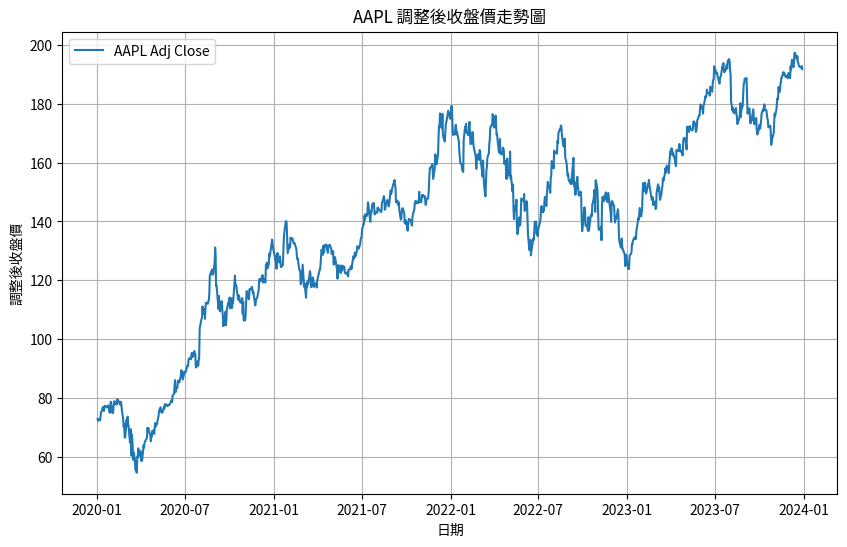

In [ ]:
import matplotlib.pyplot as plt
import yfinance as yf


# 下載蘋果公司(AAPL)的歷史數據
stock_data = yf.download('AAPL', start='2020-01-01', end='2024-01-01')

# 提取調整後的收盤價
adj_close = stock_data['Adj Close']

# 繪製收盤價走勢圖
plt.figure(figsize=(10, 6))
plt.plot(adj_close, label='AAPL Adj Close')
plt.title('AAPL 調整後收盤價走勢圖')
plt.xlabel('日期')
plt.ylabel('調整後收盤價')
plt.legend()
plt.grid(True)
plt.show()

如果要同時顯示多隻股票的也沒問題。


[*********************100%***********************]  3 of 3 completed


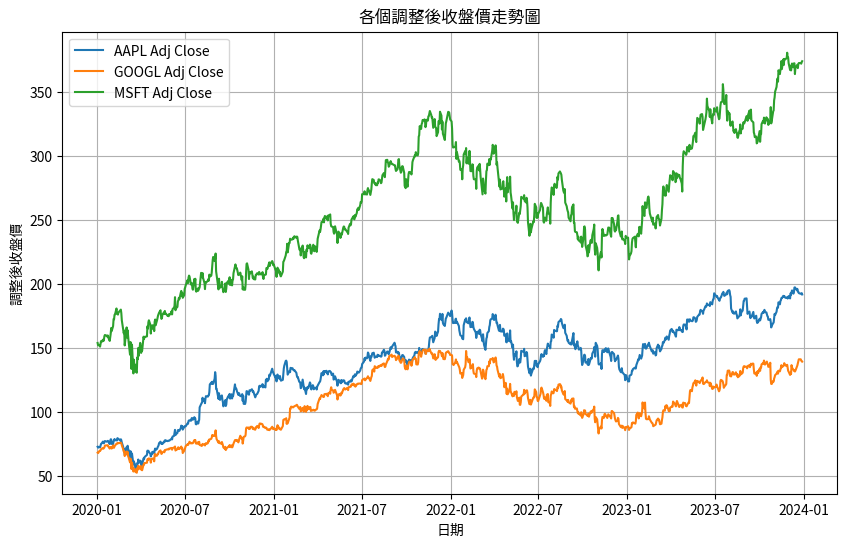

In [ ]:
import matplotlib.pyplot as plt
import yfinance as yf


# 下載多隻股票的歷史數據
stocks = ['AAPL', 'GOOGL', 'MSFT']
stock_data = yf.download(stocks, start='2020-01-01', end='2024-01-01')

# 提取調整後的收盤價
adj_close = stock_data['Adj Close']

# 繪製收盤價走勢圖
plt.figure(figsize=(10, 6))
plt.plot(adj_close, label=['AAPL Adj Close', 'GOOGL Adj Close', 'MSFT Adj Close'])
plt.title('各個調整後收盤價走勢圖')
plt.xlabel('日期')
plt.ylabel('調整後收盤價')
plt.legend()
plt.grid(True)
plt.show()

### 5. 儲存數據
在處理數據後，你可以將其保存到本地文件，以便後續分析使用：

In [ ]:
# 將數據保存為 CSV 文件
stock_data.to_csv('stock_data.csv')